Preoject outline (Saudi Dialect GPT) :
1.   Preparing the retraining data (Raw Saudi dialect text)
2.   Train GPT2 model from scratch on our Saudi data
3.   Using the retrained model to apply SFT

# 1.0 Data Preperation

## 1.1 Data pre-processing (Cleaning)

In [ ]:
import re

# Arabic Unicode ranges
arabic_pattern = re.compile(r'[^\u0600-\u06FF\s]')

# Remove emojis
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols
    "\U0001F680-\U0001F6FF"  # transport
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FAFF"
    "]+",
    flags=re.UNICODE
)

def clean_arabic_text(text):

    # remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # remove mentions
    text = re.sub(r"@\w+", " ", text)

    # remove hashtags
    text = re.sub(r"#\w+", " ", text)

    # remove emojis
    text = emoji_pattern.sub(" ", text)

    # keep only Arabic characters and spaces
    text = arabic_pattern.sub(" ", text)

    # remove excessive repeating characters (>2)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


# ---------- Process file ----------

input_file = "/content/PreTrainData_saudi_tweets.txt"
output_file = "/content/PreTrainData_saudi_tweets_clean.txt"

with open(input_file, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

print("\nSample of the raw datat:\n")
for line in lines[:5]:
    print(line.strip())
print("Total raw datat tweets:", len(lines))

clean_lines = []

for line in lines:
    cleaned = clean_arabic_text(line)

    if len(cleaned) > 2:   # avoid empty lines
        clean_lines.append(cleaned)



with open(output_file, "w", encoding="utf-8") as f:
    for line in clean_lines:
        f.write(line + "\n")

print("Cleaning finished!")
print("\nSample of the datat after cleaning:\n")
for line in clean_lines[:5]:
    print(line)
print("Total cleaned tweets:", len(clean_lines))


Sample of the raw datat:

﻿خرابيط الطاقة اعتبرها من ضمن #تجارة_الوهم https://t.co/C5PAOE4VjY May 25, 2017
@KEAlMarah اللهم آمين 👐🏻 May 25, 2017
الحرمين في مكة و المدينة لا تدوشنا يا قرد #رمضان_كريم 😊 https://t.co/bt8oHBp2Pf May 25, 2017
@4_mysterious ما كأنها يابانية ملامحها صينية 🤔 May 25, 2017
@Gifswd ثقالة دم تافه و سخيف May 25, 2017
Total raw datat tweets: 207462
Cleaning finished!

Sample of the datat after cleaning:

خرابيط الطاقة اعتبرها من ضمن
اللهم آمين
الحرمين في مكة و المدينة لا تدوشنا يا قرد
ما كأنها يابانية ملامحها صينية
ثقالة دم تافه و سخيف
Total cleaned tweets: 192125


# 2.0 Training GPT2 from scratch with retrained toknizer

In [ ]:
with open('/content/PreTrainData_saudi_tweets_clean_original.txt', "r", encoding="utf-8") as f:
    cleaned_text = f.read()

print(cleaned_text)
print("length:", len(cleaned_text))

خرابيط الطاقة اعتبرها من ضمن
اللهم آمين
الحرمين في مكة و المدينة لا تدوشنا يا قرد
ما كأنها يابانية ملامحها صينية
ثقالة دم تافه و سخيف
الشماعة الي تعلقون عليها كل بلاويكم وعليه لا بد ان تقود المرأة السيارة كود ينصلح حالكم وتتسنعون حالكم ح
حسستني ان سواقتكم توب وكل واحد فيكم يسقط ع الثاني وتتعاركون بالطريق حمدلله والشك السعودية خذت مركز متقد
آي دونت كير ، اهم شي خل يبئّون هالبحصة ونسوق
اكيد اعرف اسوق
اي هين
هه اخاف سيارتك هي الي تندمر اذا انصدمت
خل انظلك اهب يروح ويجي بسيارته مايتعطل ابد
السيارة واقفة عند الباب ونضطر نروح و نجي بتكسي
السيارة موجودة
آنا حالياً اعتبر نفسي زي الغريء الي يتعلء بئشاية اي خبر عن بيفوز برتاويت وادعي له بعد
يمكن هالمرة غير
لييش
مو هي الاميرة رفيجتها اميرة ماترابع الا اميرات يعني نفس درجة الخوي عند طويلين العمر
بعد اكثر من هالرمز و للحين مافهمت
لها علاقات رفيعة المستوى وافهم يا فهيم
الاخت اعلاه
أربت
هذا البائس مذمم آل الشيك البذيء ماعنده الجرأه ينتقد جدّه لانه مستفيد من ورى اسمه مخصصات تمشي له من الدوله
عيب استح على وجهك بالله هذا وصف تكتبه يا مدعي الثقافة الله ل

### Retraining the toknizer on my data

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("gpt2")

new_tokenizer = tokenizer.train_new_from_iterator(
    open("/content/PreTrainData_saudi_tweets_clean_original.txt", encoding="utf-8"),
    vocab_size=52000
)

new_tokenizer.save_pretrained("./arabic_tokenizer")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

('./arabic_tokenizer/tokenizer_config.json',
 './arabic_tokenizer/tokenizer.json')

Load the retrained toknizer to use it

In [ ]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("./arabic_tokenizer")

In [ ]:
vocab_dict = tokenizer.get_vocab()
print(f"Vocabulary size: {len(vocab_dict)}")

Vocabulary size: 34402


In [ ]:
for i, (token, idx) in enumerate(vocab_dict.items()):
    if i >= 20:
        break
    print(token, idx)

ĠÙĤÙħØª 9760
ĠØ§ØŃÙĬØ§ 18549
ĠØ®ÙĬØ¢ÙĦÙĬ 28156
ÙĤØ§Ø¹Ø¯Ùĩ 30020
ĠÙĪØ±ÙĬØ« 32378
ĠÙĦØ¬ÙĪØ±Ø¬ 28411
ĠØ§ÙĦÙģÙĦØ³ÙģØ© 29772
ĠØ±ØŃÙĦÙĩ 24882
ÙħØ±Ø±ÙĬ 18079
Ø§ÙĦØ´Ø±ÙĩÙĩ 13221
ĠØªÙģÙĤØ¯ÙĩØ§Ø£ÙĩÙħÙĬØªÙĩØ§ 34366
ĠÙħØ§ÙħØ§ØªÙĬ 26869
ĠØ§ÙĦÙħØ³ÙħÙĦÙĬÙĨ 28948
ÙĥØªÙĪØ± 1201
ĠØ¨Ø¹ÙħØ±ÙĩØ§ 28254
ĠØ¶Ø§ÙĬ 7571
ĠØ§ÙĦØ§Ø¨ÙĬØ¶ 11554
ĠØ§ÙĦÙĪÙĤÙģØ© 28597
ĠÙħØ§ØªØ§Ø®Ø° 10738
ĠÙĦØ§ØªØµÙĨÙģ 21122


In [ ]:
print(f"Vocabulary size: {len(vocab_dict)}")

Vocabulary size: 34402


In [ ]:
import torch

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text)
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

In [ ]:
# Example Arabic sentence
sentence = "هلا والله كيف الحال؟"

# Encode
encoded_tensor = text_to_token_ids(sentence, tokenizer)
print("Encoded token IDs:", encoded_tensor)
print("Shape:", encoded_tensor.shape)

# Decode back
decoded_text = token_ids_to_text(encoded_tensor, tokenizer)
print("Decoded text:", decoded_text)

Encoded token IDs: tensor([[2708,  481,  791, 5674,  336]])
Shape: torch.Size([1, 5])
Decoded text: هلا والله كيف الحال؟


##1.3 Data sampling with a sliding window

In [ ]:
cleaned_text

'خرابيط الطاقة اعتبرها من ضمن\nاللهم آمين\nالحرمين في مكة و المدينة لا تدوشنا يا قرد\nما كأنها يابانية ملامحها صينية\nثقالة دم تافه و سخيف\nالشماعة الي تعلقون عليها كل بلاويكم وعليه لا بد ان تقود المرأة السيارة كود ينصلح حالكم وتتسنعون حالكم ح\nحسستني ان سواقتكم توب وكل واحد فيكم يسقط ع الثاني وتتعاركون بالطريق حمدلله والشك السعودية خذت مركز متقد\nآي دونت كير ، اهم شي خل يبئّون هالبحصة ونسوق\nاكيد اعرف اسوق\nاي هين\nهه اخاف سيارتك هي الي تندمر اذا انصدمت\nخل انظلك اهب يروح ويجي بسيارته مايتعطل ابد\nالسيارة واقفة عند الباب ونضطر نروح و نجي بتكسي\nالسيارة موجودة\nآنا حالياً اعتبر نفسي زي الغريء الي يتعلء بئشاية اي خبر عن بيفوز برتاويت وادعي له بعد\nيمكن هالمرة غير\nلييش\nمو هي الاميرة رفيجتها اميرة ماترابع الا اميرات يعني نفس درجة الخوي عند طويلين العمر\nبعد اكثر من هالرمز و للحين مافهمت\nلها علاقات رفيعة المستوى وافهم يا فهيم\nالاخت اعلاه\nأربت\nهذا البائس مذمم آل الشيك البذيء ماعنده الجرأه ينتقد جدّه لانه مستفيد من ورى اسمه مخصصات تمشي له من الدوله\nعيب استح على وجهك بالله هذا وصف تكتب

In [ ]:
encoded = tokenizer.encode(cleaned_text)
print(len(cleaned_text))
print(len(encoded))

Token indices sequence length is longer than the specified maximum sequence length for this model (76762 > 1024). Running this sequence through the model will result in indexing errors


372512
76762


In [ ]:
enc_sample = encoded[40:]
enc_sample

[303,
 11231,
 597,
 1837,
 6895,
 20886,
 11761,
 29104,
 11761,
 312,
 199,
 13190,
 303,
 25899,
 9292,
 1687,
 628,
 2308,
 5952,
 285,
 1621,
 31558,
 28541,
 2136,
 24673,
 1089,
 12561,
 3378,
 10650,
 199,
 21917,
 12298,
 9470,
 708,
 1349,
 409,
 844,
 25546,
 420,
 299,
 33299,
 21886,
 199,
 1922,
 1029,
 5738,
 199,
 315,
 4643,
 199,
 616,
 5828,
 4392,
 614,
 393,
 32636,
 425,
 8661,
 199,
 457,
 30221,
 23209,
 1930,
 5831,
 30403,
 31635,
 10639,
 199,
 4535,
 24215,
 458,
 3041,
 21907,
 4078,
 277,
 5567,
 30987,
 199,
 4535,
 4360,
 199,
 4965,
 1980,
 446,
 3363,
 1303,
 908,
 22701,
 393,
 33651,
 30996,
 476,
 2200,
 348,
 13101,
 33860,
 8576,
 480,
 539,
 199,
 2110,
 18510,
 582,
 199,
 5458,
 199,
 744,
 614,
 21934,
 33065,
 19702,
 30529,
 465,
 19706,
 577,
 456,
 4345,
 19829,
 458,
 26778,
 3305,
 199,
 1446,
 793,
 301,
 33307,
 277,
 1840,
 4271,
 199,
 558,
 15154,
 31346,
 5084,
 14529,
 588,
 31131,
 199,
 12812,
 20071,
 199,
 16093,
 199,
 528,
 

In [ ]:
enc_sample[:5]

[303, 11231, 597, 1837, 6895]

In [ ]:
context_size = 30

x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]

print(f"x: {x}")
print(f"y:      {y}")

x: [303, 11231, 597, 1837, 6895, 20886, 11761, 29104, 11761, 312, 199, 13190, 303, 25899, 9292, 1687, 628, 2308, 5952, 285, 1621, 31558, 28541, 2136, 24673, 1089, 12561, 3378, 10650, 199]
y:      [11231, 597, 1837, 6895, 20886, 11761, 29104, 11761, 312, 199, 13190, 303, 25899, 9292, 1687, 628, 2308, 5952, 285, 1621, 31558, 28541, 2136, 24673, 1089, 12561, 3378, 10650, 199, 21917]


In [ ]:
x = enc_sample[:context_size]
x

[303,
 11231,
 597,
 1837,
 6895,
 20886,
 11761,
 29104,
 11761,
 312,
 199,
 13190,
 303,
 25899,
 9292,
 1687,
 628,
 2308,
 5952,
 285,
 1621,
 31558,
 28541,
 2136,
 24673,
 1089,
 12561,
 3378,
 10650,
 199]

In [ ]:
y = enc_sample[1:context_size+1]
y

[11231,
 597,
 1837,
 6895,
 20886,
 11761,
 29104,
 11761,
 312,
 199,
 13190,
 303,
 25899,
 9292,
 1687,
 628,
 2308,
 5952,
 285,
 1621,
 31558,
 28541,
 2136,
 24673,
 1089,
 12561,
 3378,
 10650,
 199,
 21917]

In [ ]:
for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]

    print(context, "---->", desired)

[303] ----> 11231
[303, 11231] ----> 597
[303, 11231, 597] ----> 1837
[303, 11231, 597, 1837] ----> 6895
[303, 11231, 597, 1837, 6895] ----> 20886
[303, 11231, 597, 1837, 6895, 20886] ----> 11761
[303, 11231, 597, 1837, 6895, 20886, 11761] ----> 29104
[303, 11231, 597, 1837, 6895, 20886, 11761, 29104] ----> 11761
[303, 11231, 597, 1837, 6895, 20886, 11761, 29104, 11761] ----> 312
[303, 11231, 597, 1837, 6895, 20886, 11761, 29104, 11761, 312] ----> 199
[303, 11231, 597, 1837, 6895, 20886, 11761, 29104, 11761, 312, 199] ----> 13190
[303, 11231, 597, 1837, 6895, 20886, 11761, 29104, 11761, 312, 199, 13190] ----> 303
[303, 11231, 597, 1837, 6895, 20886, 11761, 29104, 11761, 312, 199, 13190, 303] ----> 25899
[303, 11231, 597, 1837, 6895, 20886, 11761, 29104, 11761, 312, 199, 13190, 303, 25899] ----> 9292
[303, 11231, 597, 1837, 6895, 20886, 11761, 29104, 11761, 312, 199, 13190, 303, 25899, 9292] ----> 1687
[303, 11231, 597, 1837, 6895, 20886, 11761, 29104, 11761, 312, 199, 13190, 303, 25899

In [ ]:
for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]

    print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

 ان ---->  تقود
 ان تقود ---->  المرأة
 ان تقود المرأة ---->  السيارة
 ان تقود المرأة السيارة ---->  كود
 ان تقود المرأة السيارة كود ---->  ينصلح
 ان تقود المرأة السيارة كود ينصلح ---->  حالكم
 ان تقود المرأة السيارة كود ينصلح حالكم ---->  وتتسنعون
 ان تقود المرأة السيارة كود ينصلح حالكم وتتسنعون ---->  حالكم
 ان تقود المرأة السيارة كود ينصلح حالكم وتتسنعون حالكم ---->  ح
 ان تقود المرأة السيارة كود ينصلح حالكم وتتسنعون حالكم ح ----> 

 ان تقود المرأة السيارة كود ينصلح حالكم وتتسنعون حالكم ح
 ----> حسستني
 ان تقود المرأة السيارة كود ينصلح حالكم وتتسنعون حالكم ح
حسستني ---->  ان
 ان تقود المرأة السيارة كود ينصلح حالكم وتتسنعون حالكم ح
حسستني ان ---->  سواقتكم
 ان تقود المرأة السيارة كود ينصلح حالكم وتتسنعون حالكم ح
حسستني ان سواقتكم ---->  توب
 ان تقود المرأة السيارة كود ينصلح حالكم وتتسنعون حالكم ح
حسستني ان سواقتكم توب ---->  وكل
 ان تقود المرأة السيارة كود ينصلح حالكم وتتسنعون حالكم ح
حسستني ان سواقتكم توب وكل ---->  واحد
 ان تقود المرأة السيارة كود ينصلح حالكم وتتسنعون حالكم ح
حسستن

In [ ]:
import torch
print("PyTorch version:", torch.__version__)

PyTorch version: 2.10.0+cu128


In [ ]:
from torch.utils.data import Dataset, DataLoader
class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt)

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

In [ ]:
def create_dataloader_v1(txt, batch_size=4, max_length=1024,
                         stride=1024, shuffle=True, drop_last=True, num_workers=0):
    # Initialize the tokenizer
    tokenizer = AutoTokenizer.from_pretrained("./arabic_tokenizer")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)

    return dataloader

In [ ]:
dataloader = create_dataloader_v1(cleaned_text)

for x, y in dataloader:
    print("Input shape:", x.shape)
    print("Target shape:", y.shape)
    break

data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)

Token indices sequence length is longer than the specified maximum sequence length for this model (76762 > 1024). Running this sequence through the model will result in indexing errors


Input shape: torch.Size([4, 1024])
Target shape: torch.Size([4, 1024])
[tensor([[  346,  4938,  2094,  ...,  6050,   199,   845],
        [28671,   303,  7974,  ..., 18629, 11683,   696],
        [  303, 21171,   301,  ..., 21710,  1000,  6599],
        [ 1209,  1954,  1024,  ...,   786,  4297, 30275]]), tensor([[ 4938,  2094, 29552,  ...,   199,   845,  1208],
        [  303,  7974, 29574,  ..., 11683,   696,   346],
        [21171,   301, 17605,  ...,  1000,  6599,  1419],
        [ 1954,  1024,   530,  ...,  4297, 30275,   199]])]


In [ ]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[25504,  4809,   199,  ...,   199,   371,  1242],
        [  956,  8519,  1435,  ...,  8269,   199,  1463],
        [  199, 32266,  2795,  ...,  1238, 34077,   336],
        [  560,   199,   684,  ..., 31041,   426,   758]]), tensor([[ 4809,   199, 22094,  ...,   371,  1242,   277],
        [ 8519,  1435,   199,  ...,   199,  1463, 11486],
        [32266,  2795, 22830,  ..., 34077,   336,   199],
        [  199,   684,  1193,  ...,   426,   758, 23690]])]


In [ ]:
total_characters = len(cleaned_text)
total_tokens = len(tokenizer.encode(cleaned_text))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 372512
Tokens: 76762


# 1.3 Building the model

1.3.1 the Attention mechanism

In [ ]:
import torch.nn as nn
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by n_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)  # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.reshape(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)  # optional projection

        return context_vec


1.3.2 Normalization Layer

In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


1.3.3 Feed Forward Layer

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

1.3.4 Transformer Block

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)   # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed-forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

1.3.5 GPT model archetecture

In [ ]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [ ]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (B, T) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_token, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Get the idx of the vocab entry with the highest logits value
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [ ]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # New (not in book): numerical stability tip to get equivalent results on mps device
            # subtract rowwise max before softmax
            logits = logits - logits.max(dim=-1, keepdim=True).values

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [ ]:


if __name__ == "__main__":

    GPT_CONFIG_124M = {
        "vocab_size": 50257,     # Vocabulary size
        "context_length": 1024,  # Context length
        "emb_dim": 768,          # Embedding dimension
        "n_heads": 12,           # Number of attention heads
        "n_layers": 12,          # Number of layers
        "drop_rate": 0.1,        # Dropout rate
        "qkv_bias": False        # Query-Key-Value bias
    }

    torch.manual_seed(123)
    model = GPTModel(GPT_CONFIG_124M)
    model.eval()  # disable dropout

    start_context = "هلا والله"

    #tokenizer = tiktoken.get_encoding("gpt2")
    tokenizer = AutoTokenizer.from_pretrained("./arabic_tokenizer")
    encoded = tokenizer.encode(start_context)
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)

    print(f"\n{50*'='}\n{22*' '}IN\n{50*'='}")
    print("\nInput text:", start_context)
    print("Encoded input text:", encoded)
    print("encoded_tensor.shape:", encoded_tensor.shape)

    #out = generate_text_simple(

    out = generate(
        model=model,
        idx=encoded_tensor,
        max_new_tokens=10,
        context_size=GPT_CONFIG_124M["context_length"],
        temperature=1.4,
        top_k=10
    )
    decoded_text = tokenizer.decode(out.squeeze(0).tolist())

    print(f"\n\n{50*'='}\n{22*' '}OUT\n{50*'='}")
    print("\nOutput:", out)
    print("Output length:", len(out[0]))
    print("Output text:", decoded_text)


                      IN

Input text: هلا والله
Encoded input text: [2708, 481]
encoded_tensor.shape: torch.Size([1, 2])


                      OUT

Output: tensor([[ 2708,   481, 48898, 19401, 29411, 36543, 25787, 12945, 44109, 39147,
         43708, 48058]])
Output length: 12
Output text: هلا والله ويفسق يدرسون الآهات ماتستحي


# Training and Validation

In [ ]:
import torch

GPT_CONFIG_124M = {
    "vocab_size": len(tokenizer),   # Vocabulary size
    "context_length": 1024, # Shortened context length (orig: ) it was 256
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
#model.eval();  # Disable dropout during inference

In [ ]:
# Train/validation ratio
#train_ratio = 0.80
#split_idx = int(train_ratio * len(cleaned_text))
#train_data = cleaned_text[:split_idx]
#val_data = cleaned_text[split_idx:]

train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

total_len = len(cleaned_text)

train_end = int(train_ratio * total_len)
val_end = train_end + int(val_ratio * total_len)

train_data = cleaned_text[:train_end]
val_data = cleaned_text[train_end:val_end]
test_data = cleaned_text[val_end:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)



val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

test_loader = create_dataloader_v1(
    test_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    shuffle=False,
    drop_last=False
)


print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))



Token indices sequence length is longer than the specified maximum sequence length for this model (52352 > 1024). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (16396 > 1024). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (8016 > 1024). Running this sequence through the model will result in indexing errors


Train batches: 25
Validation batches: 8
Test batches: 4


In [ ]:
if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

optional checks

In [ ]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 102

In [ ]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 51200
Validation tokens: 16384
All tokens: 67584


loss calculation

In [ ]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

choosing a device

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")


print(f"Using {device} device.")


model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes


torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Using cuda device.
Training loss: 10.617591934204102
Validation loss: 10.61506736278534


Training function

In [ ]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        #token_ids = generate_text_simple(
        token_ids = generate(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size, temperature=1.4, top_k=10
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

Training the model

In [ ]:
import time
start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 25
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="هلا والله", tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.896, Val loss 9.537
Ep 1 (Step 000005): Train loss 9.046, Val loss 9.186
Ep 1 (Step 000010): Train loss 8.744, Val loss 8.899
Ep 1 (Step 000015): Train loss 8.646, Val loss 9.039
Ep 1 (Step 000020): Train loss 8.385, Val loss 8.992
هلا والله انا   الي الي  حتى  حتى بس    الي بسً من حتى    ان هذا  من من     الله  ان على    من من من  انا حتى اللهً من الله 
Ep 2 (Step 000025): Train loss 8.530, Val loss 8.863
Ep 2 (Step 000030): Train loss 8.372, Val loss 8.973
Ep 2 (Step 000035): Train loss 8.325, Val loss 9.008
Ep 2 (Step 000040): Train loss 8.143, Val loss 9.039
Ep 2 (Step 000045): Train loss 8.076, Val loss 9.000
هلا والله انت من الله انا انا عن من ولا انا من على هذا وين اي اذا على الله على والله من عن الولاية من الله عن من اي انا من وش لا هذا
Ep 3 (Step 000050): Train loss 8.018, Val loss 9.161
Ep 3 (Step 000055): Train loss 8.159, Val loss 9.087
Ep 3 (Step 000060): Train loss 8.083, Val loss 9.066
Ep 3 (Step 000065): Train loss 7.975, Val loss 9.404


Loss Plot

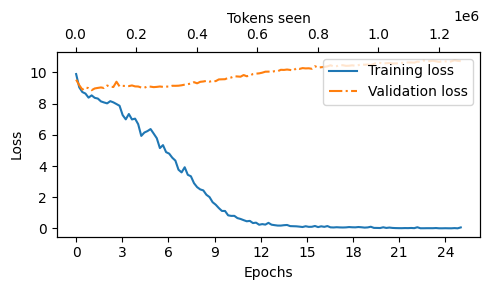

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

Inference

In [ ]:
# NEW: use CPU here as inference is cheap with
# this model and to ensure readers get same results in the
# remaining sections of this book
inference_device = torch.device("cpu")

model.to(inference_device)
model.eval()

tokenizer = AutoTokenizer.from_pretrained("./arabic_tokenizer")

#token_ids = generate_text_simple(
token_ids = generate(
    model=model,
    idx=text_to_token_ids("هذا احنا", tokenizer).to(inference_device),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"],
    temperature=1.4, top_k=10
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 هذا احنا عن الأعراق الصينيين و العرب و البذائه
ثم ان هذا الدليل الذي اوردته يتحدث عن مسؤولية الافراد بالمجتمع حتى ينفجر الفجر متفق على كيفك


Model saving

In [ ]:
torch.save(model.state_dict(), "model_fromScratch_25ep.pth")

Saving a model with the optemizer

In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    "fromScratch_25ep_model_and_optimizer.pth"
)

Loading a model

In [ ]:
model = GPTModel(GPT_CONFIG_124M)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

model.load_state_dict(torch.load("model.pth", map_location=device, weights_only=True))
model.eval();

Device: cpu


Loading the model with the optimizer

In [ ]:
#model = GPTModel(GPT_CONFIG_124M)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
else:
    device = torch.device("cpu")
    ######### اجرب اضيف هذ يالسطور اللي فوق يمكن يضبط

checkpoint = torch.load("/content/model_and_optimizer.pth", weights_only=True)

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

Loading pretrained weights from OpenAI

# 2.0 Supervied Fine_tuning

## 2.1 Preparing the dataset

### Loading the data

In [ ]:
import json
with open("/content/SFTData.json", "r", encoding="utf-8") as file:
        data = json.load(file)

In [ ]:
print("Number of entries:", len(data))

Number of entries: 11139


In [ ]:
print("Example entry:\n", data[50])

Example entry:
 {'input': 'ياهلا دلال، وشلونك؟ تدري، كنت اقرأ عن تأثير التلوث على الصحة التنفسية، خاصة في المناطق الحضرية مثل الملز.\nيا هلا عائشة، والله مشكلة التلوث صارت مرة خطيرة. يقولون الناس في الملز يعانون من أمراض تنفسية أكثر من غيرهم.\nصحيح، وربي سمعت أن نسبة الربو زادت بشكل كبير هناك. وش رايك نسوي شي نرفع الوعي عن هالشي؟\nأنا معاك، نبغى نبدأ حملة توعية في المدارس والجامعات. لازم نعلم الناس عن طرق تقليل التلوث.\nفكرة ممتازة، الله يعطيك العافية دلال. ندري أن هذا لمصلحة الجميع. يلا نتواصل مع الجهات المختصة وبنسوي خطة.', 'output': 'تسلمين عائشة، وأنا جاهزة لأي مساعدة. ماقصرتِ، يالبى قلبك، بنبدأ شغلنا من اليوم. <|endoftext|>'}


In [ ]:
def format_input(entry):
    input_text = f"\n\n### Input:\n{entry['input']}"
    return input_text

In [ ]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"

print(model_input + desired_response)



### Input:
ياهلا دلال، وشلونك؟ تدري، كنت اقرأ عن تأثير التلوث على الصحة التنفسية، خاصة في المناطق الحضرية مثل الملز.
يا هلا عائشة، والله مشكلة التلوث صارت مرة خطيرة. يقولون الناس في الملز يعانون من أمراض تنفسية أكثر من غيرهم.
صحيح، وربي سمعت أن نسبة الربو زادت بشكل كبير هناك. وش رايك نسوي شي نرفع الوعي عن هالشي؟
أنا معاك، نبغى نبدأ حملة توعية في المدارس والجامعات. لازم نعلم الناس عن طرق تقليل التلوث.
فكرة ممتازة، الله يعطيك العافية دلال. ندري أن هذا لمصلحة الجميع. يلا نتواصل مع الجهات المختصة وبنسوي خطة.

### Response:
تسلمين عائشة، وأنا جاهزة لأي مساعدة. ماقصرتِ، يالبى قلبك، بنبدأ شغلنا من اليوم. <|endoftext|>


In [ ]:
train_portion = int(len(data) * 0.85)  # 85% for training
test_portion = int(len(data) * 0.1)    # 10% for testing
val_portion = len(data) - train_portion - test_portion  # Remaining 5% for validation

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

In [ ]:
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 9468
Validation set length: 558
Test set length: 1113


### Patching the dataset

In [ ]:
import torch
from torch.utils.data import Dataset


class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data

        # Pre-tokenize texts
        self.encoded_texts = []
        for entry in data:
            input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

### Padding

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("./arabic_tokenizer")

print(tokenizer.encode("<|endoftext|>"))

[0]


In [ ]:
def custom_collate_fn(
    batch,
    pad_token_id=0,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs and targets
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets

        # New: Replace all but the first padding tokens in targets by ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # New: Optionally truncate to maximum sequence length
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs and targets to tensors and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [ ]:
#testing the padding
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[0, 1, 2, 3, 4],
        [5, 6, 0, 0, 0],
        [7, 8, 9, 0, 0]])
tensor([[   1,    2,    3,    4,    0],
        [   6,    0, -100, -100, -100],
        [   8,    9,    0, -100, -100]])


In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: cuda


In [ ]:
print(f"Torch Version: {torch.__version__}")


Torch Version: 2.10.0+cu128


In [ ]:
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)

In [ ]:
from torch.utils.data import DataLoader


num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

In [ ]:
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [ ]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 189]) torch.Size([8, 189])
torch.Size([8, 162]) torch.Size([8, 162])
torch.Size([8, 135]) torch.Size([8, 135])
torch.Size([8, 170]) torch.Size([8, 170])
torch.Size([8, 206]) torch.Size([8, 206])
torch.Size([8, 171]) torch.Size([8, 171])
torch.Size([8, 164]) torch.Size([8, 164])
torch.Size([8, 112]) torch.Size([8, 112])
torch.Size([8, 159]) torch.Size([8, 159])
torch.Size([8, 128]) torch.Size([8, 128])
torch.Size([8, 142]) torch.Size([8, 142])
torch.Size([8, 135]) torch.Size([8, 135])
torch.Size([8, 148]) torch.Size([8, 148])
torch.Size([8, 217]) torch.Size([8, 217])
torch.Size([8, 122]) torch.Size([8, 122])
torch.Size([8, 142]) torch.Size([8, 142])
torch.Size([8, 200]) torch.Size([8, 200])
torch.Size([8, 167]) torch.Size([8, 167])
torch.Size([8, 149]) torch.Size([8, 149])
torch.Size([8, 174]) torch.Size([8, 174])
torch.Size([8, 183]) torch.Size([8, 183])
torch.Size([8, 162]) torch.Size([8, 162])
torch.Size([8, 148]) torch.Size([8, 148])
torch.Size([8, 138])

In [ ]:
print(inputs[0])

tensor([  199,   199,     3,     3,     3,   221,    41,    78,    80,    85,
           84,    26,   199,   622,   266,  2986,   328,  4138,  7427,   336,
         1565,   328,   381,  3287,  9285,   499,   257,  9716,  6390,    14,
          199,   684,   444,   969, 12135,   440,   368, 12634,  1827,    14,
          504,  1316,  2635,   567,   313,   278,  1835,  1274,    14,   199,
          378,  1040,   356,   440,   567,   313,   278,  3459,  5446,   529,
           14,   504, 21533, 10273,   756,  2307,  4324,    14,   199,   199,
            3,     3,     3,   221,    50,    69,    83,    80,    79,    78,
           83,    69,    26,   199,   823,   440,   476,  1712,  4078,   283,
         3595,  9109,   336,   221,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0],
       device='cuda:0')


In [ ]:
print(targets[0])

tensor([  199,     3,     3,     3,   221,    41,    78,    80,    85,    84,
           26,   199,   622,   266,  2986,   328,  4138,  7427,   336,  1565,
          328,   381,  3287,  9285,   499,   257,  9716,  6390,    14,   199,
          684,   444,   969, 12135,   440,   368, 12634,  1827,    14,   504,
         1316,  2635,   567,   313,   278,  1835,  1274,    14,   199,   378,
         1040,   356,   440,   567,   313,   278,  3459,  5446,   529,    14,
          504, 21533, 10273,   756,  2307,  4324,    14,   199,   199,     3,
            3,     3,   221,    50,    69,    83,    80,    79,    78,    83,
           69,    26,   199,   823,   440,   476,  1712,  4078,   283,  3595,
         9109,   336,   221,     0,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100],
       device='cuda:0')


### Load a pretrained model

in the following 4 celles we are evaluating the model without trainig, so we will se that it still cant follow instructions

In [ ]:
import torch
# -------------------------
# Configuration
# -------------------------
GPT_CONFIG_124M = {
    "vocab_size": 34402,        # <-- use your tokenizer's vocab size
    "context_length": 1024,     # <-- same as used during training
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

# -------------------------
# Device setup
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -------------------------
# Load checkpoint
# -------------------------
checkpoint_path = "/content/fromScratch_25ep_model_and_optimizer.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)

# -------------------------
# Initialize model
# -------------------------
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)

# -------------------------
# Initialize optimizer
# -------------------------
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# Move optimizer states to correct device (important for GPU)
for state in optimizer.state.values():
    for k, v in state.items():
        if isinstance(v, torch.Tensor):
            state[k] = v.to(device)

# -------------------------
# Set model mode
# -------------------------
# For inference:
model.eval()

# For continued training, uncomment:
# model.train()

# -------------------------
# Example usage (inference)
# -------------------------
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("./arabic_tokenizer")
start_context = "هلا والله"
encoded = tokenizer.encode(start_context)
input_tensor = torch.tensor(encoded).unsqueeze(0).to(device)

# Simple generation loop
max_new_tokens = 20
context_size = GPT_CONFIG_124M["context_length"]
idx = input_tensor

for _ in range(max_new_tokens):
    with torch.no_grad():
        logits = model(idx[:, -context_size:])
    logits = logits[:, -1, :]
    next_token = torch.argmax(logits, dim=-1, keepdim=True)
    idx = torch.cat([idx, next_token], dim=1)

output_text = tokenizer.decode(idx.squeeze(0).tolist())
print("Generated text:", output_text)


Using device: cuda
Generated text: هلا والله انه من الممكن ان يكون الخادم وليي
ثم ان هذا الدليل الذي اوردته يتحدث عن مسؤولية الافراد بالمجتمع حتى


In [ ]:
torch.manual_seed(123)

input_text = format_input(val_data[0])
print(input_text)



### Input:
طيب جماعة، اليوم بنبدأ نتكلم عن النظام الجديد ERP.
وش هالنظام يتطلب بالضبط؟
النظام بيكون شامل لكل الأمور المالية والإدارية.


In [ ]:
import torch

# Set device to CUDA if available, otherwise fall back to CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# Move the model to the selected device (GPU or CPU)
model.to(device)

# Convert input text to token IDs and move to the same device as the model
input_ids = text_to_token_ids(input_text, tokenizer).to(device)

# Generate tokens with the model
token_ids = generate(
    model=model,
    idx=input_ids,  # Ensure input_ids are on the same device as the model
    max_new_tokens=35,
    context_size=1024,
    eos_id=0,
)

# Convert token IDs back to text
generated_text = token_ids_to_text(token_ids, tokenizer)

In [ ]:
response_text = (
    generated_text[len(input_text):]
    .replace("### Response:", "")
    .strip()
)
print(response_text)

الاخت رنا ترد على امثالك
خلينا الفكر لك اقعد فكر على كيف كيفك محد بيقول لك لا
برنامج لقياس اثر المدرسة النفسي لطلاب المرحلة الابتدائية أو المرحلة الثانويه او للمرحلة الجامعية


## Finetuning the LLM on instruction data

In [ ]:
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 11.574486923217773
Validation loss: 11.413889503479004


In [ ]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.1)

num_epochs =  2
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.831, Val loss 9.670
Ep 1 (Step 000005): Train loss 7.576, Val loss 7.382
Ep 1 (Step 000010): Train loss 6.619, Val loss 6.352
Ep 1 (Step 000015): Train loss 5.975, Val loss 5.708
Ep 1 (Step 000020): Train loss 5.391, Val loss 5.280
Ep 1 (Step 000025): Train loss 5.264, Val loss 4.997
Ep 1 (Step 000030): Train loss 5.022, Val loss 4.828
Ep 1 (Step 000035): Train loss 4.837, Val loss 4.747
Ep 1 (Step 000040): Train loss 4.771, Val loss 4.657
Ep 1 (Step 000045): Train loss 4.881, Val loss 4.586
Ep 1 (Step 000050): Train loss 4.696, Val loss 4.559
Ep 1 (Step 000055): Train loss 4.489, Val loss 4.500
Ep 1 (Step 000060): Train loss 4.667, Val loss 4.456
Ep 1 (Step 000065): Train loss 4.614, Val loss 4.418
Ep 1 (Step 000070): Train loss 4.426, Val loss 4.395
Ep 1 (Step 000075): Train loss 4.575, Val loss 4.358
Ep 1 (Step 000080): Train loss 4.314, Val loss 4.340
Ep 1 (Step 000085): Train loss 4.478, Val loss 4.329
Ep 1 (Step 000090): Train loss 4.481, Val loss

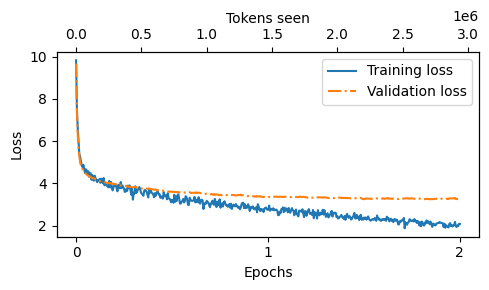

In [ ]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [ ]:
torch.manual_seed(123)


for entry in test_data[:4]:

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=40,
        context_size=1024,
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
)

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")



### Input:
وش رايك في المكان؟ جلسة هادية مره.
وربي رهيب، هالجو رايق. تدري إني دايم أحب أجي هنا.
ايه والله، انا بعد. طيب، وش رأيك بموضوع الأكل الحلال؟ ليش حنا نركز عليه كذا؟

Correct response:
>> ياخي الأكل الحلال مهم مره، ما هو بس عن الأكل، بعد عن الطهارة والنظافة. <|endoftext|>

Model response:
>> ايه، بس تدري، يقولون انه بيسوي كذا. <|endoftext|> في الرياض؟ <|endoftext|>. <|endoftext|> في الرياض؟
-------------------------------------


### Input:
وش رايك في المكان؟ جلسة هادية مره.
وربي رهيب، هالجو رايق. تدري إني دايم أحب أجي هنا.
ايه والله، انا بعد. طيب، وش رأيك بموضوع الأكل الحلال؟ ليش حنا نركز عليه كذا؟
ياخي الأكل الحلال مهم مره، ما هو بس عن الأكل، بعد عن الطهارة والنظافة.
ما قصرت، صدقت. طبعاً، الله يبي لنا الخير، وهالشي ينطبق على كل شي في حياتنا.

Correct response:
>> بالضبط، له تأثير كبير على الروح والجسد. والله كل شي ببركة من رب العالمين يعطينا خيره. <|endoftext|>

Model response:
>> ما شاء الله، الله يعطيك العافية. <|endoftext|>. <|endoftext|> في خدمة. <|endoftext|>. <|endofte

In [ ]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):

    if i >= 20:  # Stop after 20 samples
        break

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=40,
        context_size=1024,
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()

    test_data[i]["model_response"] = response_text


with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)  # "indent" for pretty-printing

  2%|▏         | 20/1113 [00:12<11:26,  1.59it/s]


In [ ]:
import torch
from torch import nn
import math
from tqdm import tqdm

# -------------------------
# Define loss function (Cross-Entropy Loss)
# -------------------------
loss_fn = nn.CrossEntropyLoss()

# -------------------------
# Initialize Perplexity Calculation
# -------------------------
total_loss = 0.0
num_samples = 0

# -------------------------
# Iterate over the test data
# -------------------------
for i, entry in tqdm(enumerate(test_data), total=len(test_data)):

    if i >= 1113:  # Stop after 20 samples
        break

    input_text = format_input(entry)

    # Tokenize input text (using text_to_token_ids as in your code)
    input_tensor = text_to_token_ids(input_text, tokenizer).to(device)

    # Prepare the true labels (shift the input tokens by 1 to predict the next token)
    labels = input_tensor[:, 1:].contiguous()  # True next tokens (shifted)
    input_tensor = input_tensor[:, :-1]  # Input without the last token

    # -------------------------
    # Get logits from the model (forward pass)
    # -------------------------
    with torch.no_grad():
        logits = model(input_tensor)  # Logits shape: (batch_size, seq_len, vocab_size)

    # Reshape logits and labels to match the CrossEntropyLoss requirement
    # Shape of logits: (batch_size * seq_len, vocab_size)
    logits = logits.view(-1, GPT_CONFIG_124M["vocab_size"])  # Flatten logits
    labels = labels.view(-1)  # Flatten labels

    # -------------------------
    # Calculate cross-entropy loss for the entire sequence
    # -------------------------
    loss = loss_fn(logits, labels)

    # -------------------------
    # Accumulate loss for perplexity calculation
    # -------------------------
    total_loss += loss.item()
    num_samples += 1

# -------------------------
# Average loss and compute perplexity
# -------------------------
avg_loss = total_loss / num_samples  # Mean loss over all samples
perplexity = math.exp(avg_loss)  # Exponentiate the average loss to get perplexity

print(f"Perplexity: {perplexity}")

100%|██████████| 1113/1113 [00:17<00:00, 63.21it/s]

Perplexity: 26.250363468107498


In [ ]:
print(test_data[0])


{'input': 'وش رايك في المكان؟ جلسة هادية مره.\nوربي رهيب، هالجو رايق. تدري إني دايم أحب أجي هنا.\nايه والله، انا بعد. طيب، وش رأيك بموضوع الأكل الحلال؟ ليش حنا نركز عليه كذا؟', 'output': 'ياخي الأكل الحلال مهم مره، ما هو بس عن الأكل، بعد عن الطهارة والنظافة. <|endoftext|>', 'model_response': 'ايه، بس تدري، يقولون انه بيسوي كذا. <|endoftext|> في الرياض؟ <|endoftext|>. <|endoftext|> في الرياض؟'}


saving the model

In [ ]:
import re

file_name = "sftmodel.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

# Load model via
# model.load_state_dict(torch.load("gpt2-medium355M-sft.pth"))

Model saved as sftmodel.pth


# 3.0 Retrain a pretrainig GPT2 model on my saudi dialect dataset

In [ ]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [ ]:
def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params["wpe"])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params["wte"])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])


In [ ]:
import os
import json

import numpy as np
import requests
import tensorflow as tf
from tqdm import tqdm


def download_and_load_gpt2(model_size, models_dir):
    # Validate model size
    allowed_sizes = ("124M", "355M", "774M", "1558M")
    if model_size not in allowed_sizes:
        raise ValueError(f"Model size not in {allowed_sizes}")

    # Define paths
    model_dir = os.path.join(models_dir, model_size)
    base_url = "https://openaipublic.blob.core.windows.net/gpt-2/models"
    backup_base_url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/gpt2"
    filenames = [
        "checkpoint", "encoder.json", "hparams.json",
        "model.ckpt.data-00000-of-00001", "model.ckpt.index",
        "model.ckpt.meta", "vocab.bpe"
    ]

    # Download files
    os.makedirs(model_dir, exist_ok=True)
    for filename in filenames:
        file_url = os.path.join(base_url, model_size, filename)
        backup_url = os.path.join(backup_base_url, model_size, filename)
        file_path = os.path.join(model_dir, filename)
        download_file(file_url, file_path, backup_url)

    # Load settings and params
    tf_ckpt_path = tf.train.latest_checkpoint(model_dir)
    settings = json.load(open(os.path.join(model_dir, "hparams.json"), "r", encoding="utf-8"))
    params = load_gpt2_params_from_tf_ckpt(tf_ckpt_path, settings)

    return settings, params


def download_file(url, destination, backup_url=None):
    def _attempt_download(download_url):
        response = requests.get(download_url, stream=True, timeout=60)
        response.raise_for_status()

        file_size = int(response.headers.get("Content-Length", 0))

        # Check if file exists and has same size
        if os.path.exists(destination):
            file_size_local = os.path.getsize(destination)
            if file_size and file_size == file_size_local:
                print(f"File already exists and is up-to-date: {destination}")
                return True

        block_size = 1024  # 1 KB
        desc = os.path.basename(download_url)
        with tqdm(total=file_size, unit="iB", unit_scale=True, desc=desc) as progress_bar:
            with open(destination, "wb") as file:
                for chunk in response.iter_content(chunk_size=block_size):
                    if chunk:
                        file.write(chunk)
                        progress_bar.update(len(chunk))
        return True

    try:
        if _attempt_download(url):
            return
    except requests.exceptions.RequestException:
        if backup_url is not None:
            print(f"Primary URL ({url}) failed. Attempting backup URL: {backup_url}")
            try:
                if _attempt_download(backup_url):
                    return
            except requests.exceptions.RequestException:
                pass

        error_message = (
            f"Failed to download from both primary URL ({url})"
            f"{' and backup URL (' + backup_url + ')' if backup_url else ''}."
            "\nCheck your internet connection or the file availability.\n"
            "For help, visit: https://github.com/rasbt/LLMs-from-scratch/discussions/273"
        )
        print(error_message)
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


def load_gpt2_params_from_tf_ckpt(ckpt_path, settings):
    # Initialize parameters dictionary with empty blocks for each layer
    params = {"blocks": [{} for _ in range(settings["n_layer"])]}

    # Iterate over each variable in the checkpoint
    for name, _ in tf.train.list_variables(ckpt_path):
        # Load the variable and remove singleton dimensions
        variable_array = np.squeeze(tf.train.load_variable(ckpt_path, name))

        # Process the variable name to extract relevant parts
        variable_name_parts = name.split("/")[1:]  # Skip the 'model/' prefix

        # Identify the target dictionary for the variable
        target_dict = params
        if variable_name_parts[0].startswith("h"):
            layer_number = int(variable_name_parts[0][1:])
            target_dict = params["blocks"][layer_number]

        # Recursively access or create nested dictionaries
        for key in variable_name_parts[1:-1]:
            target_dict = target_dict.setdefault(key, {})

        # Assign the variable array to the last key
        last_key = variable_name_parts[-1]
        target_dict[last_key] = variable_array

    return params

In [ ]:
# ما قدرت اسوي رن لان كان لازم اخلي الماكس لنقث ١٠٢٤ لكن عشان الداتا قليله ما يضبط اجرب لما اجي اسوي الرن بالتادا الكبيره

############################################
# Load pretrained GPT-2 weights
############################################

import numpy as np
import time

CHOOSE_MODEL = "gpt2-small (124M)"

model_configs = {
    "gpt2-small (124M)": {
        "emb_dim": 768,
        "n_layers": 12,
        "n_heads": 12
    }
}

# update config to match GPT2 architecture
GPT_CONFIG_124M.update(model_configs[CHOOSE_MODEL])
GPT_CONFIG_124M["vocab_size"] = 50257
GPT_CONFIG_124M["qkv_bias"] = True

print("Downloading pretrained GPT-2 weights...")

settings, params = download_and_load_gpt2(
    model_size="124M",
    models_dir="gpt2"
)

############################################
# Initialize model and load weights
############################################

torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M)

load_weights_into_gpt(model, params)

model.to(device)

print("Pretrained GPT-2 weights loaded successfully.")

############################################
# Evaluate before retraining
############################################

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Initial training loss:", train_loss)
print("Initial validation loss:", val_loss)

############################################
# Retrain GPT-2 on Saudi tweets
############################################

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-5,          # small LR for finetuning
    weight_decay=0.1
)

num_epochs = 5

start_time = time.time()

train_losses, val_losses, tokens_seen = train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs=num_epochs,
    eval_freq=5,
    eval_iter=5,
    start_context="هلا والله",
    tokenizer=tokenizer
)

end_time = time.time()

print(f"\nTraining completed in {(end_time-start_time)/60:.2f} minutes.")

############################################
# Final evaluation
############################################

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("\nFinal training loss:", train_loss)
print("Final validation loss:", val_loss)

############################################
# Generate sample Saudi text
############################################

model.eval()

start_context = "هلا والله"

encoded = text_to_token_ids(start_context, tokenizer).to(device)

with torch.no_grad():
    token_ids = generate(
        model=model,
        idx=encoded,
        max_new_tokens=50,
        context_size=GPT_CONFIG_124M["context_length"],
        temperature=1.2,
        top_k=10
    )

generated_text = token_ids_to_text(token_ids, tokenizer)

print("\nGenerated text:")
print(generated_text)

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


ValueError: Shape mismatch. Left: torch.Size([128, 768]), Right: (1024, 768)